# Global Superstore Performance Analysis: Revenue, Profitability & Customer Insights (2011-2014)

**Gambaran Bisnis / Business Overview**

ID:

Analisis ini mengevaluasi performa penjualan dan profitabilitas Global Superstore selama periode 2011–2014. Tujuannya adalah mengidentifikasi tren pertumbuhan bisnis, performa market, profitabilitas produk, serta nilai pelanggan untuk mendukung pengambilan keputusan strategis.

EN:

This analysis evaluates the sales and profitability performance of Global Superstore between 2011 and 2014. The objective is to identify growth trends, market performance, product profitability, and customer value in order to support strategic business decisions.

**Tools :**
*   Google Colab (SQL + Python Analysis)
*   BigQuery SQLite at Colab
*   Looker Studio (Dashboard)
*   Github (Portfolio Hosting)

**Business Case :**

ID :

Management ingin mengetahui :
1. Bagaimana performa penjualan dan profit penjualan?
2. Apakah bisnis tumbuh dari tahun ke tahun?
3. Negara dan market mana yang memberikan kontribusi terbesar?
4. Produk apa yang paling menguntungkan?
5. Apakah diskon mempengaruhi profit?
6. Segmen customer mana yang paling bernilai?
7. Area mana yang perlu diperhatikan karena profit rendah?

EN :

Management wants to understand :
1. What is the overall sales and profit performance?
2. How has the business grown over time (Year-over-Year)?
3. Which countries and markets are the top contributors to sales and profit?
4. What are the most profitable products?
5. How do discounts affect profit margins?
6. Which customer segments generate the most value?
7. Which regions should be prioritized for improvement due to low or negative profit?




# Connect to GDrive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import Library

In [ ]:
import os
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load Dataset

In [ ]:
#path definition
path="/content/drive/MyDrive/Portfolio/Global Super Store Dataset/Global_Superstore2.csv"

#Read data
df=pd.read_csv(path, encoding='latin1')

## Initial Exploration

In [ ]:
#Menampilan data teratas / Preview Data

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [ ]:
#Menampilkan bentuk dataset / Show dataset

df.shape

(51290, 24)

In [ ]:
#Menampilkan informasi data / Showing dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [ ]:
#Statistical Summary

df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296804
min,1.00000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12823.25000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000


# Data Cleaning / Data Quality Check

## Missing Value

In [ ]:
missing = pd.DataFrame ({
    'total_missing': df.isnull().sum(),
    'perc_missing': (df.isnull().sum()/df.shape[0])*100
    })

missing.sort_values(by='perc_missing', ascending=False)

,total_missing,perc_missing
Postal Code,41296,80.51472
Row ID,0,0.00000
Order Date,0,0.00000
Order ID,0,0.00000
Ship Mode,0,0.00000
Customer ID,0,0.00000
Customer Name,0,0.00000
Ship Date,0,0.00000
Segment,0,0.00000
City,0,0.00000


**ID : **Postal code memiliki nilai missing value yang tinggi, namun dikarena tidak berpengaruh apapun pada analisis maka tidak ada data yang perlu diubah

**EN : **The postal code column has a high number of missing values. However, since it does not affect the analysis, no data modifications are required.

## Duplicate Check

In [ ]:
#Menghitung jumlah total data duplikat / Calculating the total number of duplicate records
duplicate_count = df.duplicated().sum()

print(f"Total Duplicate Rows: {duplicate_count}")

Total Duplicate Rows: 0


## Standarize/Fix Structural Error

### Standarize Column Name

In [ ]:
df.columns = (
    df.columns
      .str.strip()
      .str.replace(' ','_', regex=False)
      .str.replace('-','_', regex=False)
      .str.replace('/','_', regex=False)
)

df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'City', 'State', 'Country',
       'Postal_Code', 'Market', 'Region', 'Product_ID', 'Category',
       'Sub_Category', 'Product_Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping_Cost', 'Order_Priority'],
      dtype='object')

### Convert Date Column

In [ ]:
# Order Date

df['Order_Date'] = pd.to_datetime(
    df['Order_Date'],
    dayfirst=True,
    errors='coerce'
)

In [ ]:
# Ship Date

df['Ship_Date'] = pd.to_datetime(
    df['Ship_Date'],
    dayfirst=True,
    errors='coerce'
)

In [ ]:
# Validate Date Conversion
df[['Order_Date','Ship_Date']].head()

,Order_Date,Ship_Date
0,2012-07-31,2012-07-31
1,2013-02-05,2013-02-07
2,2013-10-17,2013-10-18
3,2013-01-28,2013-01-30
4,2013-11-05,2013-11-06


### Change Data Type

In [ ]:
df = df.astype({'Postal_Code': 'str',
                'Quantity': 'int64'})

## Check Outlier

In [ ]:
# Sales

df['Sales'].describe()

,Sales
count,51290.000000
mean,246.490581
std,487.565361
min,0.444000
25%,30.758625
50%,85.053000
75%,251.053200
max,22638.480000


In [ ]:
# Profit

df['Profit'].describe()

,Profit
count,51290.000000
mean,28.610982
std,174.340972
min,-6599.978000
25%,0.000000
50%,9.240000
75%,36.810000
max,8399.976000


## Create Date Features

### Year

In [ ]:
df['Order_Year'] = df['Order_Date'].dt.year

### Month Number

In [ ]:
df['Order_Month'] = df['Order_Date'].dt.month

### Month Name

In [ ]:
df['Order_Month'] = df['Order_Date'].dt.strftime('%B')

### Quarter

In [ ]:
df['Order_Quarter'] = df['Order_Date'].dt.quarter

### Year Month

In [ ]:
df['Year_Month'] = df['Order_Date'].dt.strftime('%Y-%m')

In [ ]:
# Check Date Range
print(df['Order_Date'].min())
print(df['Order_Date'].max())

2011-01-01 00:00:00
2014-12-31 00:00:00


In [ ]:
# Check Negative Sales
df[df['Sales'] < 0]

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,City,State,...,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Order_Year,Order_Month,Order_Quarter,Year_Month


In [ ]:
# Check Negative Profit
df[df['Profit'] < 0]

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,City,State,...,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Order_Year,Order_Month,Order_Quarter,Year_Month
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,3709.395,9,0.1,-288.7650,923.63,Critical,2013,February,1,2013-02
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,2892.510,5,0.1,-96.5400,910.16,Medium,2013,January,1,2013-01
9,40936,CA-2012-116638,2012-01-28,2012-01-31,Second Class,JH-15985,Joseph Holt,Consumer,Concord,North Carolina,...,4297.644,13,0.4,-1862.3124,865.74,Critical,2012,January,1,2012-01
30,220,US-2011-128776,2011-12-28,2011-12-30,Second Class,RR-19525,Rick Reed,Corporate,Santo Domingo,Santo Domingo,...,1696.640,5,0.2,-148.4600,704.06,Critical,2011,December,4,2011-12
32,32735,CA-2012-139731,2012-10-15,2012-10-15,Same Day,JE-15745,Joel Eaton,Consumer,Amarillo,Texas,...,2453.430,5,0.3,-350.4900,690.42,High,2012,October,4,2012-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51276,31558,US-2014-155299,2014-06-09,2014-06-13,Standard Class,Dl-13600,Dorris liebe,Corporate,Pasadena,Texas,...,1.624,2,0.8,-4.4660,0.02,Medium,2014,June,2,2014-06
51278,43818,NI-2011-4700,2011-09-08,2011-09-10,Second Class,PO-8865,Patrick O'Donnell,Consumer,Lagos,Lagos,...,5.364,1,0.7,-6.4560,0.02,High,2011,September,3,2011-09
51279,46231,ZI-2011-4350,2011-03-21,2011-03-26,Standard Class,AS-285,Alejandro Savely,Corporate,Harare,Harare,...,9.612,2,0.7,-21.1680,0.02,Medium,2011,March,1,2011-03
51280,46582,TU-2014-6730,2014-11-29,2014-11-30,First Class,KF-6285,Karen Ferguson,Home Office,Midyat,Mardin,...,34.128,6,0.6,-49.5720,0.02,Medium,2014,November,4,2014-11


## Profit Margin

In [ ]:
#Create Profit Margin
df['Profit_Margin'] = np.where(
    df['Sales'] != 0,
    (df['Profit'] / df['Sales']) * 100,
    0
)

profit_margin = df[['Sales', 'Profit', 'Profit_Margin']]
profit_margin.head()

,Sales,Profit,Profit_Margin
0,2309.650,762.1845,33.000000
1,3709.395,-288.7650,-7.784693
2,5175.171,919.9710,17.776630
3,2892.510,-96.5400,-3.337586
4,2832.960,311.5200,10.996272


## Shipping Efficiency

In [ ]:
df['Shipping_Efficiency'] = np.where(
    (df['Ship_Date'] - df['Order_Date']).dt.days != 0,
    (df['Sales'] / (df['Ship_Date'] - df['Order_Date']).dt.days),
    np.nan  # Assign NaN for cases where Ship_Date and Order_Date are the same, to avoid division by zero
)

shipping_efficiency = df[['Sales', 'Ship_Date', 'Order_Date', 'Shipping_Efficiency']]
shipping_efficiency.head()

,Sales,Ship_Date,Order_Date,Shipping_Efficiency
0,2309.650,2012-07-31,2012-07-31,NaN
1,3709.395,2013-02-07,2013-02-05,1854.6975
2,5175.171,2013-10-18,2013-10-17,5175.1710
3,2892.510,2013-01-30,2013-01-28,1446.2550
4,2832.960,2013-11-06,2013-11-05,2832.9600


## Shipping Cost Ratio

In [ ]:
#Create Shipping Cost Ratio
df['Shipping_Cost_Ratio'] = np.where(
    df['Sales'] != 0,
    (df['Shipping_Cost'] / df['Sales']) * 100,
    0
)

shipping_cost_ratio = df[['Sales', 'Shipping_Cost', 'Shipping_Cost_Ratio']]
shipping_cost_ratio.head()

,Sales,Shipping_Cost,Shipping_Cost_Ratio
0,2309.650,933.57,40.420410
1,3709.395,923.63,24.899748
2,5175.171,915.49,17.690043
3,2892.510,910.16,31.466097
4,2832.960,903.04,31.876200


## Delivery Days

In [ ]:
#Create Delivery Days
df['Delivery_Days'] = (
    df['Ship_Date'] - df['Order_Date']
).dt.days

delivery_days = df[['Order_Date', 'Ship_Date', 'Delivery_Days']]
delivery_days.head()

,Order_Date,Ship_Date,Delivery_Days
0,2012-07-31,2012-07-31,0
1,2013-02-05,2013-02-07,2
2,2013-10-17,2013-10-18,1
3,2013-01-28,2013-01-30,2
4,2013-11-05,2013-11-06,1


## Final Dataset Validation

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Row_ID               51290 non-null  int64         
 1   Order_ID             51290 non-null  object        
 2   Order_Date           51290 non-null  datetime64[ns]
 3   Ship_Date            51290 non-null  datetime64[ns]
 4   Ship_Mode            51290 non-null  object        
 5   Customer_ID          51290 non-null  object        
 6   Customer_Name        51290 non-null  object        
 7   Segment              51290 non-null  object        
 8   City                 51290 non-null  object        
 9   State                51290 non-null  object        
 10  Country              51290 non-null  object        
 11  Postal_Code          51290 non-null  object        
 12  Market               51290 non-null  object        
 13  Region               51290 non-

# Load data into SQLite

In [ ]:
conn = sqlite3.connect('superstore.db')

# Save Data to SQL Table

In [ ]:
df.to_sql(
    'superstore',
    conn,
    if_exists='replace',
    index=False
)

51290

In [ ]:
# Test Query

query = """
SELECT *
FROM superstore
LIMIT 5
"""

pd.read_sql(query, conn)

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,City,State,...,Shipping_Cost,Order_Priority,Order_Year,Order_Month,Order_Quarter,Year_Month,Profit_Margin,Shipping_Efficiency,Shipping_Cost_Ratio,Delivery_Days
0,32298,CA-2012-124891,2012-07-31 00:00:00,2012-07-31 00:00:00,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,933.57,Critical,2012,July,3,2012-07,33.000000,NaN,40.420410,0
1,26341,IN-2013-77878,2013-02-05 00:00:00,2013-02-07 00:00:00,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,923.63,Critical,2013,February,1,2013-02,-7.784693,1854.6975,24.899748,2
2,25330,IN-2013-71249,2013-10-17 00:00:00,2013-10-18 00:00:00,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,915.49,Medium,2013,October,4,2013-10,17.776630,5175.1710,17.690043,1
3,13524,ES-2013-1579342,2013-01-28 00:00:00,2013-01-30 00:00:00,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,910.16,Medium,2013,January,1,2013-01,-3.337586,1446.2550,31.466097,2
4,47221,SG-2013-4320,2013-11-05 00:00:00,2013-11-06 00:00:00,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,903.04,Critical,2013,November,4,2013-11,10.996272,2832.9600,31.876200,1


# Extract Data to csv

In [ ]:
df.to_csv(
    '/content/drive/MyDrive/Portfolio/Global Super Store Dataset/superstore_clean.csv',
    index=False
)

# EDA (Explorasi Data Analysis)

## Data Understanding

In [ ]:
#check unique value
for col in [
    'Market',
    'Region',
    'Country',
    'Segment',
    'Category',
    'Sub_Category'
]:
    print(f"{col}: {df[col].nunique()}")

Market: 7
Region: 13
Country: 147
Segment: 3
Category: 3
Sub_Category: 17


## Executive KPI Analysis

### Total Sales

In [ ]:
sales = """ SELECT
                round(sum(Sales),2) as total_sales
            FROM superstore
        """
sales=pd.read_sql(sales,conn)
value_sales = sales.iloc[0, 0]

print(f"Total Sales : {value_sales}")

Total Sales : 12642501.91


### Total Profit

In [ ]:
profit = """ SELECT
                 round(sum(Profit),2) as total_profit
             FROM superstore
         """
profit=pd.read_sql(profit,conn)
value_profit = profit.iloc[0, 0]

print(f"Total Profit : {value_profit}")

Total Profit : 1467457.29


### Profit Margin

In [ ]:
margin = """ SELECT
                 round ((sum(Profit)/sum(Sales))*100,2) as profit_margin
             FROM superstore
         """
margin=pd.read_sql(margin,conn)
value_margin = margin.iloc[0, 0]


print(f"profit margin : {value_margin}%")

profit margin : 11.61%


### Total Orders

In [ ]:
order = """ SELECT
                 count(distinct Order_ID) as total_order
             FROM superstore
         """
order=pd.read_sql(order,conn)
value_order = order.iloc[0, 0]

print(f"Total Order : {value_order}")

Total Order : 25035


### Total Customers

In [ ]:
cust =""" SELECT
                count(distinct Customer_ID) as total_customer
            FROM superstore
        """
cust=pd.read_sql(cust,conn)
value_cust = cust.iloc[0, 0]

print(f"Total Customer : {value_cust}")

Total Customer : 1590


### Average Order Value

In [ ]:
order_value = """ SELECT
                      round(sum(Sales)/count(distinct Order_ID),2) as avg_order_value
                  FROM superstore
              """
order_value=pd.read_sql(order_value,conn)
value_order_value = order_value.iloc[0, 0]

print(f"Average Order Value : {value_order_value}")

Average Order Value : 504.99


# Business Analysis

## Sales Trend Analysis by Year

In [ ]:
tren = """ SELECT
                 Order_Year,
                 round(sum(Sales),2) as total_sales,
                 round(sum(Profit),2) as total_profit
             FROM superstore
             GROUP BY Order_Year
             ORDER BY Order_Year
         """
tren=pd.read_sql(tren,conn)
tren

,Order_Year,total_sales,total_profit
0,2011,2259450.90,248940.81
1,2012,2677438.69,307415.28
2,2013,3405746.45,406935.23
3,2014,4299865.87,504165.97


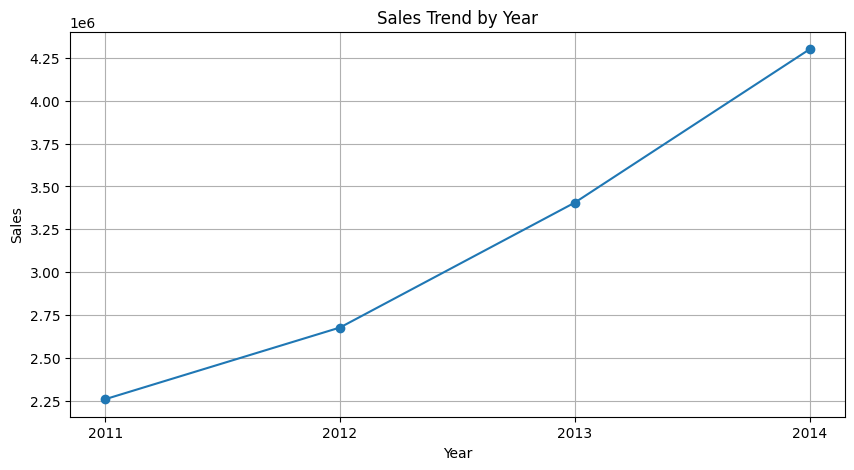

In [ ]:
# Visualisasi Sales Tren / Sales Trend Visualization

plt.figure(figsize=(10,5))

plt.plot(
    tren['Order_Year'],
    tren['total_sales'],
    marker='o'
)

plt.title('Sales Trend by Year')
plt.xlabel('Year')
plt.ylabel('Sales')

plt.xticks(tren['Order_Year'])

plt.grid(True)

plt.show()

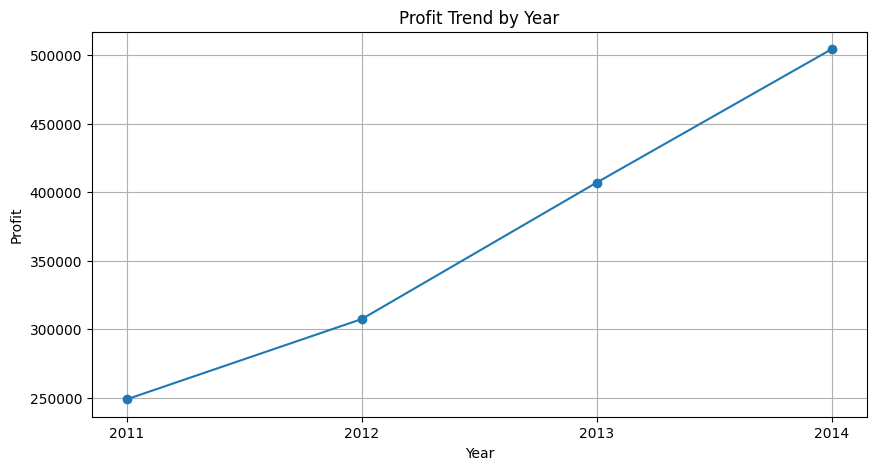

In [ ]:
# Visualisasi Profit Tren / Profit Trend Visualization

plt.figure(figsize=(10,5))

plt.plot(
    tren['Order_Year'],
    tren['total_profit'],
    marker='o'
)

plt.title('Profit Trend by Year')
plt.xlabel('Year')
plt.ylabel('Profit')

plt.xticks(tren['Order_Year'])

plt.grid(True)

plt.show()

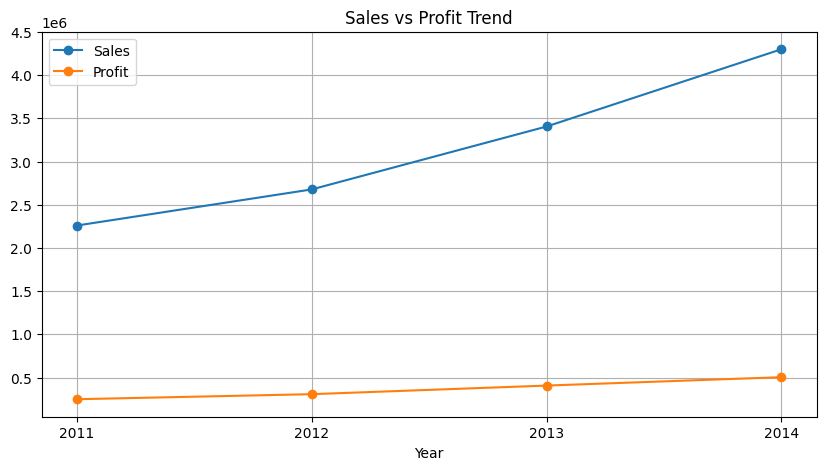

In [ ]:
# Visualisasi Sales vs Profit / Sales vs Profit Visualization

plt.figure(figsize=(10,5))

plt.plot(
    tren['Order_Year'],
    tren['total_sales'],
    marker='o',
    label='Sales'
)

plt.plot(
    tren['Order_Year'],
    tren['total_profit'],
    marker='o',
    label='Profit'
)

plt.title('Sales vs Profit Trend')
plt.xlabel('Year')

plt.xticks(tren['Order_Year'])

plt.legend()

plt.grid(True)

plt.show()

## Monthly Trend

In [ ]:
season = """ SELECT
                 CAST(strftime('%m', Order_Date) AS INTEGER) AS Order_Month_Num,
                 Order_Month,
                 round(sum(Sales),2) as total_sales
             FROM superstore
             GROUP BY Order_Month_Num,
                      Order_Month
             ORDER BY Order_Month_Num
         """
season =pd.read_sql(season,conn)
season

,Order_Month_Num,Order_Month,total_sales
0,1,January,675133.67
1,2,February,543739.38
2,3,March,770500.94
3,4,April,698561.21
4,5,May,904012.34
5,6,June,1269716.75
6,7,July,749381.84
7,8,August,1293833.17
8,9,September,1437380.11
9,10,October,1168184.39


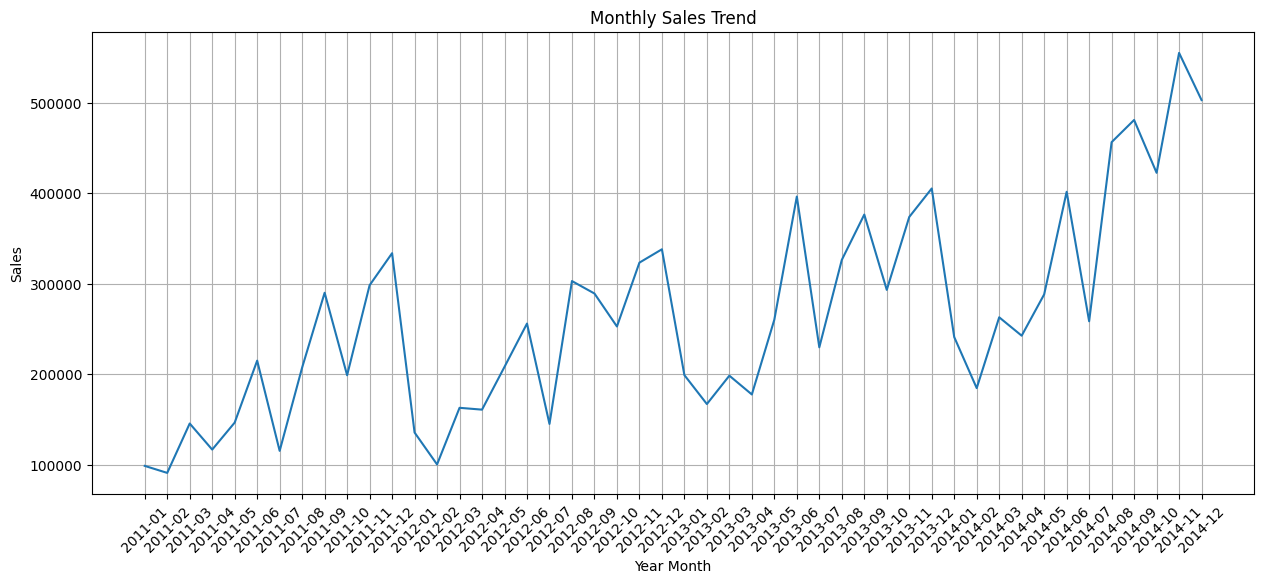

In [ ]:
#visualisasi monthly sales tren / Monthly Sales Trend Visualization

# Define monthly_sales DataFrame
monthly_sales = """ SELECT
                        Year_Month,
                        round(sum(Sales),2) as total_sales,
                        round(sum(Profit),2) as total_profit
                    FROM superstore
                    GROUP BY Year_Month
                    ORDER BY Year_Month
                """
monthly_sales = pd.read_sql(monthly_sales, conn)

plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales['Year_Month'],
    monthly_sales['total_sales']
)

plt.title('Monthly Sales Trend')
plt.xlabel('Year Month')
plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

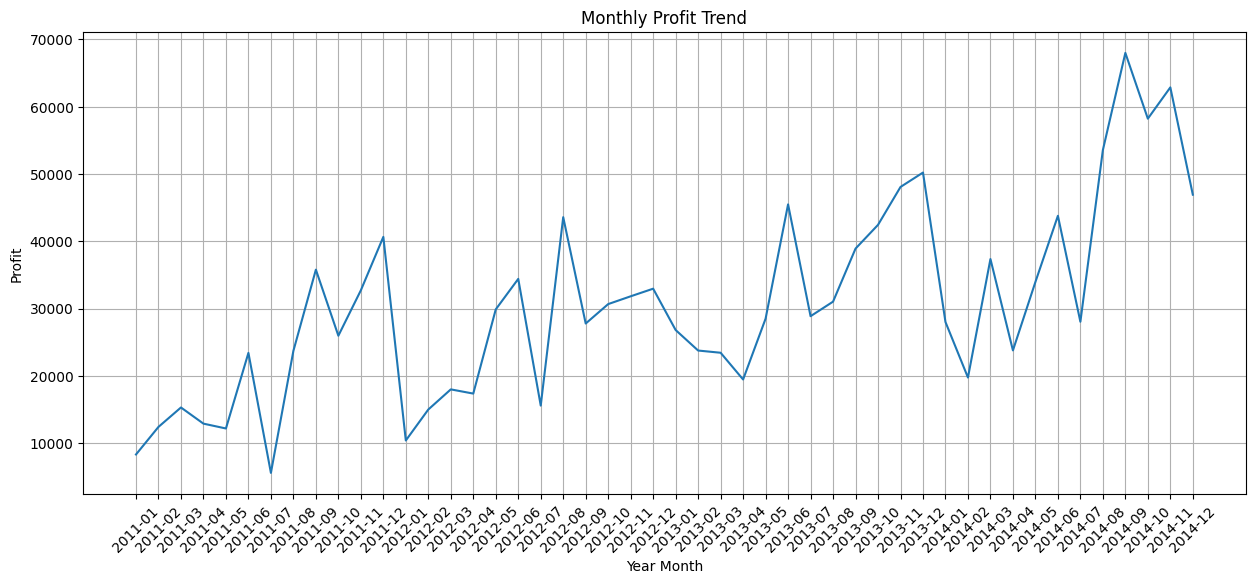

In [ ]:
# Visualisasi Monthly Profit Tren / Monthly Profit Trend Visualization

# Redefine monthly_sales DataFrame to ensure 'total_profit' is included
monthly_sales = """ SELECT
                        Year_Month,
                        round(sum(Sales),2) as total_sales,
                        round(sum(Profit),2) as total_profit
                    FROM superstore
                    GROUP BY Year_Month
                    ORDER BY Year_Month
                """
monthly_sales = pd.read_sql(monthly_sales, conn)

plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales['Year_Month'],
    monthly_sales['total_profit']
)

plt.title('Monthly Profit Trend')
plt.xlabel('Year Month')
plt.ylabel('Profit')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

### Seasonality Analysis

In [ ]:
seasonality = pd.read_sql("""
SELECT
    CAST(strftime('%m', Order_Date) AS INTEGER) AS Order_Month_Num,
    Order_Month,
    ROUND(AVG(Sales),2) AS Avg_Sales
FROM superstore
GROUP BY
    Order_Month_Num,
    Order_Month
ORDER BY Order_Month_Num
""", conn)

seasonality

,Order_Month_Num,Order_Month,Avg_Sales
0,1,January,259.77
1,2,February,250.80
2,3,March,253.87
3,4,April,228.51
4,5,May,241.26
5,6,June,238.18
6,7,July,236.70
7,8,August,254.79
8,9,September,240.57
9,10,October,260.17


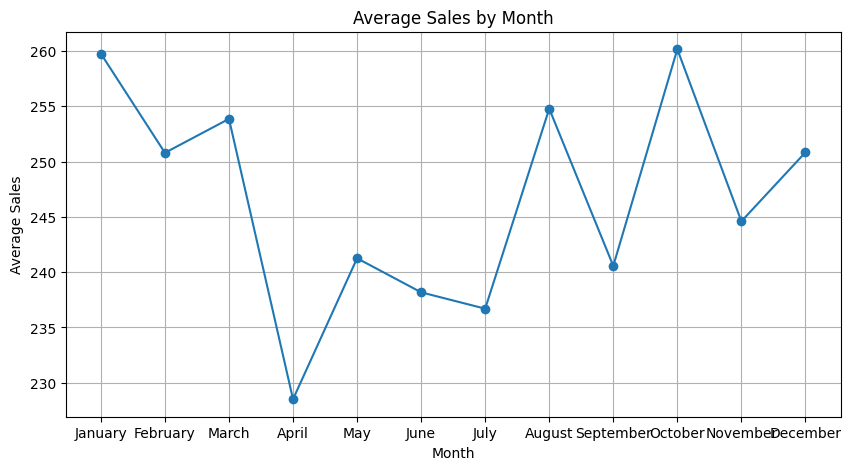

In [ ]:
# Visualisasi Seasonality / Seasonality Visualization
plt.figure(figsize=(10,5))

plt.plot(
    seasonality['Order_Month'],
    seasonality['Avg_Sales'],
    marker='o'
)

plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')

plt.grid(True)

plt.show()

### Monthly Order Tren

In [ ]:
monthly_orders = pd.read_sql("""
SELECT
    Year_Month,
    COUNT(DISTINCT Order_ID) AS Total_Orders
FROM superstore
GROUP BY Year_Month
ORDER BY Year_Month
""", conn)

monthly_orders

,Year_Month,Total_Orders
0,2011-01,216
1,2011-02,183
2,2011-03,277
3,2011-04,267
4,2011-05,295
5,2011-06,468
6,2011-07,250
7,2011-08,443
8,2011-09,527
9,2011-10,401


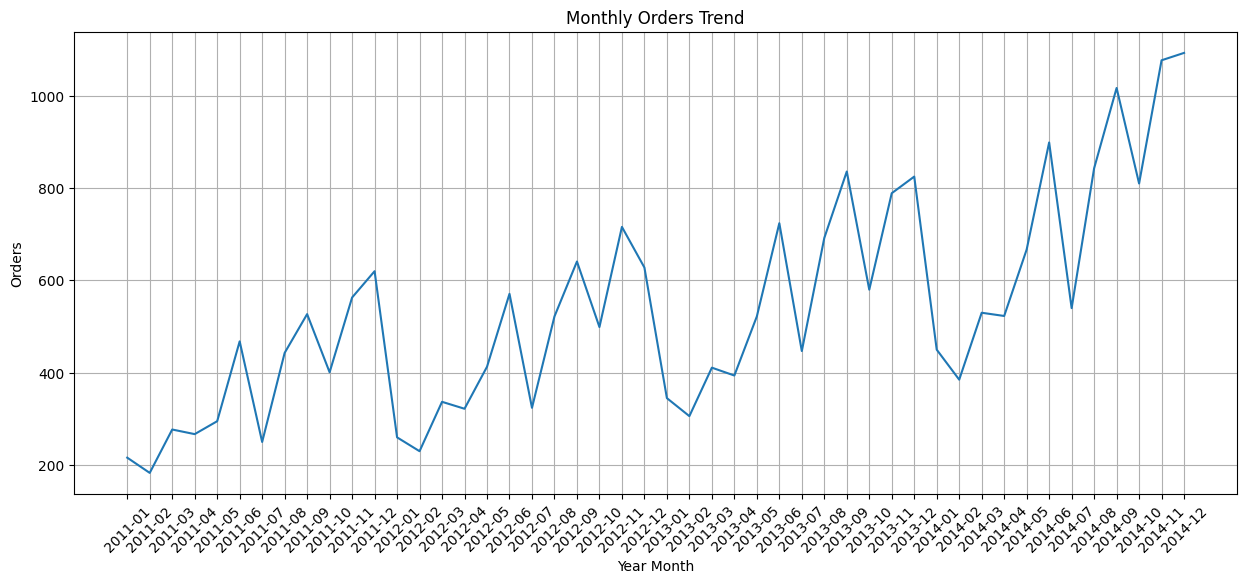

In [ ]:
#visualisasi monthly order tren

plt.figure(figsize=(15,6))

plt.plot(
    monthly_orders['Year_Month'],
    monthly_orders['Total_Orders']
)

plt.title('Monthly Orders Trend')
plt.xlabel('Year Month')
plt.ylabel('Orders')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

### Average Order Value (AOV)

In [ ]:
aov = pd.read_sql("""
SELECT
    Year_Month,

    ROUND(
        SUM(Sales) /
        COUNT(DISTINCT Order_ID),
    2) AS AOV

FROM superstore

GROUP BY Year_Month

ORDER BY Year_Month
""", conn)

aov.head()

,Year_Month,AOV
0,2011-01,457.86
1,2011-02,498.10
2,2011-03,526.10
3,2011-04,437.89
4,2011-05,497.45


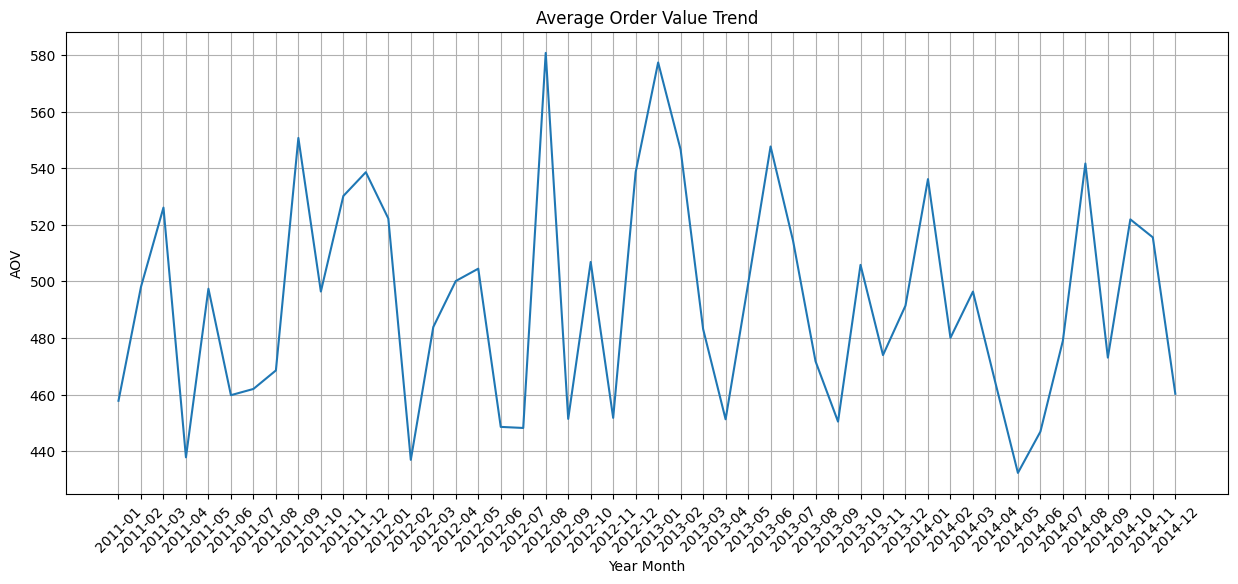

In [ ]:
#VISUALISASI AOV
plt.figure(figsize=(15,6))

plt.plot(
    aov['Year_Month'],
    aov['AOV']
)

plt.title('Average Order Value Trend')
plt.xlabel('Year Month')
plt.ylabel('AOV')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

## Market Performance

In [ ]:
# Profit per Region
market = """ SELECT
                 Region,
                 round(sum(Sales),2) as total_sales,
                 round(sum(Profit),2) as total_profit,
                 round((sum(Profit)/sum(Sales))*100,2) as profit_margin
             FROM superstore
             GROUP BY Market
             ORDER BY total_sales desc
         """
market=pd.read_sql(market,conn)
market

,Region,total_sales,total_profit,profit_margin
0,Oceania,3585744.13,436000.05,12.16
1,Central,2938089.06,372829.74,12.69
2,East,2297200.86,286397.02,12.47
3,South,2164605.17,221643.49,10.24
4,EMEA,806161.31,43897.97,5.45
5,Africa,783773.21,88871.63,11.34
6,Canada,66928.17,17817.39,26.62


In [ ]:
# Profit per Market
mgn = """ SELECT Market,
                 ROUND(SUM(Sales),2) AS total_sales,
                 ROUND(SUM(Profit),2) AS total_profit,
                 ROUND(SUM(Profit)/SUM(Sales)*100,2) AS profit_margin
          FROM superstore
          GROUP BY Market
          ORDER BY sales DESC
       """
mgn=pd.read_sql(mgn,conn)
mgn

,Market,total_sales,total_profit,profit_margin
0,Canada,66928.17,17817.39,26.62
1,APAC,3585744.13,436000.05,12.16
2,EU,2938089.06,372829.74,12.69
3,Africa,783773.21,88871.63,11.34
4,EMEA,806161.31,43897.97,5.45
5,US,2297200.86,286397.02,12.47
6,LATAM,2164605.17,221643.49,10.24


## Country performance

In [ ]:
# Top 10 Sales

country_sales=""" SELECT Country,
                         round(sum(Sales),2) as total_sales
                  FROM superstore
                  GROUP BY Country
                  ORDER BY total_sales desc
                  LIMIT 10
              """
country_sales=pd.read_sql(country_sales,conn)
country_sales

,Country,total_sales
0,United States,2297200.86
1,Australia,925235.85
2,France,858931.08
3,China,700562.03
4,Germany,628840.03
5,Mexico,622590.62
6,India,589650.10
7,United Kingdom,528576.30
8,Indonesia,404887.50
9,Brazil,361106.42


In [ ]:
# Top 10 Profit

country_profit = """ SELECT Country,
                            ROUND(SUM(Profit),2) AS total_profit,
                            ROUND((SUM(Profit)/SUM(Sales))*100,2) as perc_profit
                    FROM superstore
                    GROUP BY Country
                    ORDER BY total_profit DESC
                    LIMIT 10
                """
country_profit=pd.read_sql(country_profit,conn)
country_profit

,Country,total_profit,perc_profit
0,United States,286397.02,12.47
1,China,150683.09,21.51
2,India,129071.84,21.89
3,United Kingdom,111900.15,21.17
4,France,109029.00,12.69
5,Germany,107322.82,17.07
6,Australia,103907.43,11.23
7,Mexico,102818.10,16.51
8,Spain,54390.12,18.94
9,El Salvador,42023.24,23.67


## Negative Profit Analysis

In [ ]:
neg_prof = """ SELECT Country,
                      ROUND(SUM(Sales),2) AS sales,
                      ROUND(SUM(Profit),2) AS profit
                FROM superstore
                GROUP BY Country
                HAVING SUM(Profit) < 0
                ORDER BY profit
            """

neg_prof=pd.read_sql(neg_prof,conn)
neg_prof

,Country,sales,profit
0,Turkey,108507.95,-98447.23
1,Nigeria,54350.35,-80750.72
2,Netherlands,77514.95,-41070.08
3,Honduras,90125.65,-29482.37
4,Pakistan,58872.61,-22446.65
5,Argentina,57511.78,-18693.80
6,Panama,51539.93,-17723.45
7,Sweden,30491.40,-17519.37
8,Philippines,183420.17,-16128.22
9,South Korea,33125.38,-12792.83


## Customer Segmentation

In [ ]:
cust_segment = """SELECT Segment,
                         ROUND(SUM(Sales),2) AS sales,
                         ROUND(SUM(Profit),2) AS profit,
                         COUNT(DISTINCT Customer_ID) AS customers
                  FROM superstore
                  GROUP BY Segment
                  ORDER BY sales DESC
                """
cust_segment=pd.read_sql(cust_segment,conn)
cust_segment

,Segment,sales,profit,customers
0,Consumer,6507949.42,749239.78,818
1,Corporate,3824697.52,441208.33,476
2,Home Office,2309854.97,277009.18,296


In [ ]:
a="""SELECT Segment,
       ROUND(SUM(Sales)/COUNT(DISTINCT Customer_ID),2) AS revenue_per_customer
FROM superstore
GROUP BY Segment
ORDER BY revenue_per_customer DESC
"""

a=pd.read_sql(a,conn)
a

,Segment,revenue_per_customer
0,Corporate,8035.08
1,Consumer,7955.93
2,Home Office,7803.56


## Category performance

In [ ]:
cat_perform = """ SELECT Category,
                          ROUND(SUM(Sales),2) AS sales,
                          ROUND(SUM(Profit),2) AS profit
                  FROM superstore
                  GROUP BY Category
                  ORDER BY sales DESC
              """

cat_perform=pd.read_sql(cat_perform,conn)
cat_perform

,Category,sales,profit
0,Technology,4744557.50,663778.73
1,Furniture,4110874.19,285204.72
2,Office Supplies,3787070.23,518473.83


In [ ]:
cat_margin="""SELECT Category,
            ROUND(SUM(Profit)/SUM(Sales)*100,2) AS margin
     FROM superstore
     GROUP BY Category
     ORDER BY margin DESC
   """

cat_margin=pd.read_sql(cat_margin,conn)
cat_margin

,Category,margin
0,Technology,13.99
1,Office Supplies,13.69
2,Furniture,6.94


## Subcategory performance

In [ ]:
subcat_perform = """ SELECT Sub_Category,
                             ROUND(SUM(Sales),2) AS sales,
                             ROUND(SUM(Profit),2) AS profit
                      FROM superstore
                      GROUP BY Sub_Category
                      ORDER BY profit DESC
                  """
subcat_perform = pd.read_sql(subcat_perform, conn)
subcat_perform

,Sub_Category,sales,profit
0,Copiers,1509436.27,258567.55
1,Phones,1706824.14,216717.01
2,Bookcases,1466572.24,161924.42
3,Appliances,1011064.30,141680.59
4,Chairs,1501681.76,140396.27
5,Accessories,749237.02,129626.31
6,Storage,1127085.86,108461.49
7,Binders,461911.51,72449.85
8,Paper,244291.72,59207.68
9,Machines,779060.07,58867.87


### Negative Profit by Subcategories

In [ ]:
neg_profit_subcategories = """SELECT
Sub_Category,
ROUND(SUM(Profit),2) AS profit
FROM superstore
GROUP BY Sub_Category
ORDER BY profit
LIMIT 10
"""

neg_profit_subcategories = pd.read_sql(neg_profit_subcategories, conn)
neg_profit_subcategories

,Sub_Category,profit
0,Tables,-64083.39
1,Fasteners,11525.42
2,Labels,15010.51
3,Supplies,22583.26
4,Envelopes,29601.12
5,Furnishings,46967.43
6,Art,57953.91
7,Machines,58867.87
8,Paper,59207.68
9,Binders,72449.85


## Product analysis

In [ ]:
product_profit = """SELECT
Product_Name,
ROUND(SUM(Profit),2) AS profit
FROM superstore
GROUP BY Product_Name
ORDER BY profit DESC
LIMIT 20
"""
product_profit = pd.read_sql(product_profit, conn)
product_profit

,Product_Name,profit
0,Canon imageCLASS 2200 Advanced Copier,25199.93
1,"Cisco Smart Phone, Full Size",17238.52
2,"Motorola Smart Phone, Full Size",17027.11
3,"Hoover Stove, Red",11807.97
4,"Sauder Classic Bookcase, Traditional",10672.07
5,"Harbour Creations Executive Leather Armchair, ...",10427.33
6,"Nokia Smart Phone, Full Size",9938.20
7,"Cisco Smart Phone, with Caller ID",9786.64
8,"Nokia Smart Phone, with Caller ID",9465.33
9,"Belkin Router, USB",8955.02


## Customer analysis

In [ ]:
customer_performance = """SELECT
Customer_Name,
ROUND(SUM(Sales),2) AS sales,
ROUND(SUM(Profit),2) AS profit,
COUNT(DISTINCT Order_ID) AS orders
FROM superstore
GROUP BY Customer_Name
ORDER BY sales DESC
LIMIT 20
"""
customer_performance = pd.read_sql(customer_performance, conn)
customer_performance

,Customer_Name,sales,profit,orders
0,Tom Ashbrook,40488.07,6311.98,30
1,Tamara Chand,37457.33,8672.90,36
2,Greg Tran,35550.95,5214.13,34
3,Christopher Conant,35187.08,5603.33,39
4,Sean Miller,35170.93,-409.71,28
5,Bart Watters,32310.45,3595.89,45
6,Natalie Fritzler,31781.26,1542.82,43
7,Fred Hopkins,30400.67,4609.29,39
8,Jane Waco,30288.45,6265.85,40
9,Hunter Lopez,30243.57,7816.57,24


## Discount Impact Analysis

In [ ]:
discount_profit = """SELECT
Discount,
ROUND(AVG(Profit),2)
AS avg_profit
FROM superstore
GROUP BY Discount
ORDER BY Discount
"""
discount_profit = pd.read_sql(discount_profit, conn)
discount_profit

,Discount,avg_profit
0,0.000,61.04
1,0.002,125.76
2,0.070,140.99
3,0.100,63.68
4,0.150,50.60
5,0.170,38.32
6,0.200,23.55
7,0.202,-14.52
8,0.250,4.04
9,0.270,-4.32


### Discount by Grouping

In [ ]:
discount_group = """SELECT
CASE
WHEN Discount = 0 THEN 'No Discount'
WHEN Discount <= 0.2 THEN 'Low'
WHEN Discount <= 0.5 THEN 'Medium'
ELSE 'High'
END AS discount_group,

ROUND(SUM(Sales),2) sales,
ROUND(SUM(Profit),2) profit

FROM superstore

GROUP BY discount_group
"""
discount_group = pd.read_sql(discount_group, conn)
discount_group

,discount_group,sales,profit
0,High,371624.66,-412581.66
1,Low,3719880.18,511444.10
2,Medium,1558586.12,-402100.43
3,No Discount,6992410.95,1770695.27


## Shipping Analysis

In [ ]:
shipping_analysis = """SELECT
Market,
ROUND(SUM(Shipping_Cost),2) AS shipping_cost,
ROUND(SUM(Sales),2) AS sales,
ROUND(SUM(Shipping_Cost)/SUM(Sales)*100,2) AS shipping_ratio

FROM superstore
GROUP BY Market
ORDER BY shipping_ratio DESC
"""

shipping_analysis = pd.read_sql(shipping_analysis, conn)
shipping_analysis

,Market,shipping_cost,sales,shipping_ratio
0,Africa,88139.47,783773.21,11.25
1,Canada,7405.63,66928.17,11.07
2,EMEA,88375.73,806161.31,10.96
3,LATAM,234138.61,2164605.17,10.82
4,APAC,387165.11,3585744.13,10.80
5,EU,309422.35,2938089.06,10.53
6,US,238173.79,2297200.86,10.37


## Customer Lifetime Value (Pseudo CLV)

In [ ]:
customer_clv = """SELECT
Customer_Name,

COUNT(DISTINCT Order_ID)
AS orders,

ROUND(SUM(Sales),2)
AS sales,

ROUND(SUM(Profit),2)
AS profit

FROM superstore

GROUP BY Customer_Name

ORDER BY profit DESC

LIMIT 20
"""

customer_clv = pd.read_sql(customer_clv, conn)
customer_clv

,Customer_Name,orders,sales,profit
0,Tamara Chand,36,37457.33,8672.90
1,Raymond Buch,29,29602.14,8453.05
2,Sanjit Chand,35,26521.13,8205.38
3,Hunter Lopez,24,30243.57,7816.57
4,Bill Eplett,42,28479.17,7410.01
5,Harry Marie,41,28476.94,6958.29
6,Susan Pistek,32,29020.60,6484.41
7,Mike Gockenbach,27,23377.07,6458.68
8,Adrian Barton,40,25123.18,6417.28
9,Tom Ashbrook,30,40488.07,6311.98


# Forecast

In [ ]:
# Aggregate Monthly Sales

monthly_forecast = pd.read_sql("""
SELECT
    Year_Month,
    SUM(Sales) AS Sales
FROM superstore
GROUP BY Year_Month
ORDER BY Year_Month
""", conn)

monthly_forecast.head()

,Year_Month,Sales
0,2011-01,98898.48886
1,2011-02,91152.15698
2,2011-03,145729.36736
3,2011-04,116915.76418
4,2011-05,146747.83610


In [ ]:
# Convert Date

monthly_forecast['Year_Month'] = pd.to_datetime(
    monthly_forecast['Year_Month']
)

monthly_forecast = monthly_forecast.rename(
    columns={
        'Year_Month':'ds',
        'Sales':'y'
    }
)

In [ ]:
# Forecast with Propet

!pip install prophet

from prophet import Prophet

model = Prophet()

model.fit(monthly_forecast)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
# Forecast dalam 12 bulan kedepan

future = model.make_future_dataframe(
    periods=12,
    freq='M'
)

forecast = model.predict(future)

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


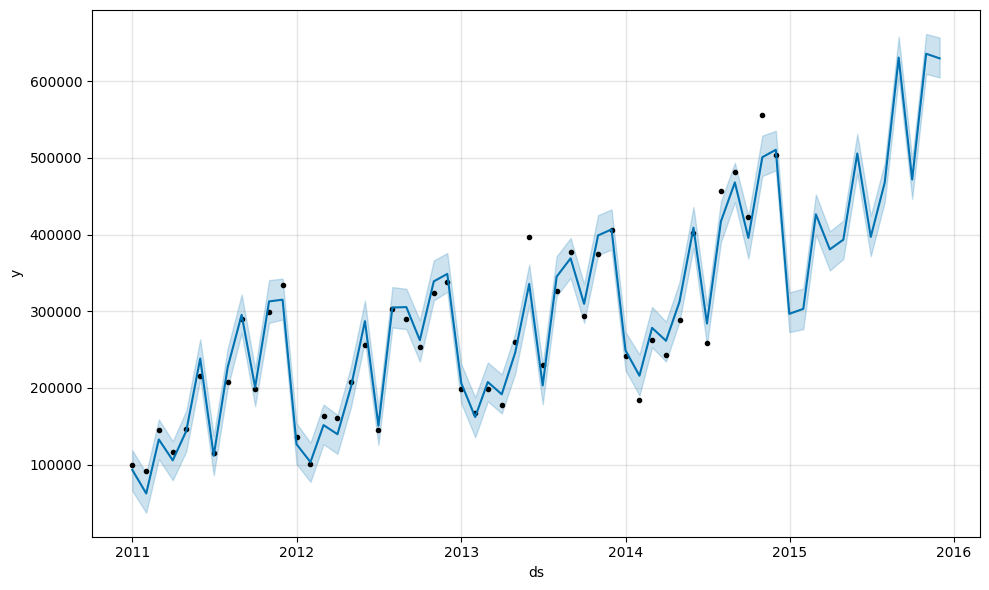

In [ ]:
# Visualisasi Forecast

fig = model.plot(forecast)

# Executive Summary

**Overall Business Performance:**

| KPI             |     Value |
| --------------- | --------: |
| Total Sales     |   12.64 Mio |
| Total Profit    |    1.47 Mio |
| Profit Margin   |    11.61% |
| Analysis Period | 2011–2014 |

ID:
Perusahaan menghasilkan revenue sebesar 12.64 juta dollar dan profit sebesar 1.47 juta dollar selama periode analisis dengan profit margin sekitar 11.6%.

EN:

The company generated 12.64 Mio dollar in revenue and 1.47 Mio dollars in profit during the analysis period, resulting in an overall profit margin of approximately 11.6%.

**Temuan Utama / Key Findings:**
1. Bisnis bertumbuh tiap tahun/Business grew consistently every year

Sales and Profit Growth

| Year |  Sales   | Profit |
| ---- | -----:   | -----: |
| 2011 | 2.26 Mio | 248.9K |
| 2012 | 2.68 Mio | 307.4K |
| 2013 | 3.41 Mio | 406.9K |
| 2014 | 4.30 Mio | 504.2K |

ID:

Penjualan dan profit meningkat secara konsisten selama periode analisis. Revenue hampir dua kali lipat dari 2.26 juta dollars pada tahun 2011 menjadi 4.30 juta dollars pada tahun 2014, menunjukkan pertumbuhan bisnis yang kuat dan permintaan pelanggan yang terus meningkat.

EN:

Both revenue and profit increased steadily throughout the analysis period. Revenue nearly doubled from 2.26M dollars in 2011 to 4.30M dollars in 2014, indicating strong business expansion and sustained customer demand.

2. APAC menjadi market kontribusi revenue terbesar/APA was the largest revenue contributing market

| Market |  Sales   | Profit |
| ------ | -----:   | -----: |
| APAC   | 3.59 Mio |  436K |
| EU     | 2.94 Mio |  373K |
| US     | 2.30 Mio |  286K |
| LATAM  | 2.16 Mio |  222K |

ID:

APAC menghasilkan revenue dan profit tertinggi dibanding market lainnya sehingga menjadi penggerak utama pertumbuhan bisnis perusahaan.

EN:

APAC generated the highest revenue and profit among all markets, making it the primary growth driver for the business.

3. Technology menjadi kategori paling menguntungkan/Technology was the most profitable category
| Category        |  Sales   | Profit |
| --------------- | -----:   | -----: |
| Technology      | 4.74 Mio |  664K |
| Office Supplies | 3.79 Mio |  518K |
| Furniture       | 4.11 Mio |  285K |

ID:

Technology menghasilkan profit tertinggi meskipun bukan kategori dengan penjualan terbesar. Furniture memiliki penjualan yang tinggi namun profit yang relatif rendah, yang mengindikasikan adanya tantangan pada margin keuntungan.

EN:

Technology delivered the highest profit despite not having the highest sales contribution. Furniture generated strong revenue but significantly lower profitability, suggesting margin challenges.

4. Segmen consumer menjadi segmen pelanggan paling bernilai/Consumer segment was the most valuable customer group
| Segment     |  Sales   | Profit |
| ----------- | -----:   | -----: |
| Consumer    | 6.51 Mio |  749K  |
| Corporate   | 3.82 Mio |  441K  |
| Home Office | 2.31 Mio |  277K  |

ID:

Segmen Consumer menyumbang lebih dari separuh total revenue dan menghasilkan profit terbesar sehingga menjadi segmen pelanggan yang paling bernilai bagi perusahaan.

EN:

Consumer customers contributed more than half of total revenue and generated the highest overall profit, making them the most valuable customer segment.

5. Beberapa negara menghasilkan profit negatif/Several Countries Generated Negative Profit

Top loss-making countries:
| Country     | Profit |
| ----------- | -----: |
| Turkey      |  -98K |
| Nigeria     |  -81K |
| Netherlands |  -41K |
| Honduras    |  -29K |
| Pakistan    |  -22K |

ID:

Walaupun menghasilkan penjualan, beberapa negara mencatat profit negatif. Hal ini mengindikasikan adanya masalah pada strategi harga, kebijakan diskon, biaya logistik, atau efisiensi operasional.

EN:

Despite generating sales, several countries reported negative profitability. This indicates potential issues related to pricing strategy, discount policies, logistics costs, or operational efficiency.

**Business Recommendation:**
1. Expand High-Performing Markets

ID: Tingkatkan investasi dan aktivitas komersial pada market APAC dan EU yang menunjukkan performa penjualan dan profit terbaik.

EN: Increase investment and commercial activities in APAC and EU markets where sales and profitability are strongest.

2. Optimize Furniture Profitability

ID: Tinjau strategi harga, biaya pemasok, dan diskon pada kategori Furniture untuk meningkatkan margin keuntungan.

EN: Review pricing, supplier costs, and discount strategies for Furniture products to improve margins.

3. Strengthen Customer Retention Programs

ID: Fokus mempertahankan pelanggan segmen Consumer karena memberikan kontribusi revenue dan profit terbesar.

EN: Focus on retaining Consumer segment customers, as they generate the largest revenue and profit contribution.

4. Investigate Loss-Making Countries

ID: Lakukan investigasi lebih lanjut pada Turkey, Nigeria, dan negara lain yang merugi untuk menemukan akar penyebab profit negatif.

EN: Conduct deeper analysis on Turkey, Nigeria, and other loss-making countries to identify root causes of negative profitability.

5. Monitor Discount Impact

ID: Evaluasi efektivitas program diskon agar pertumbuhan penjualan tidak mengorbankan profitabilitas perusahaan.

EN: Evaluate discount effectiveness to ensure revenue growth does not come at the expense of profitability.